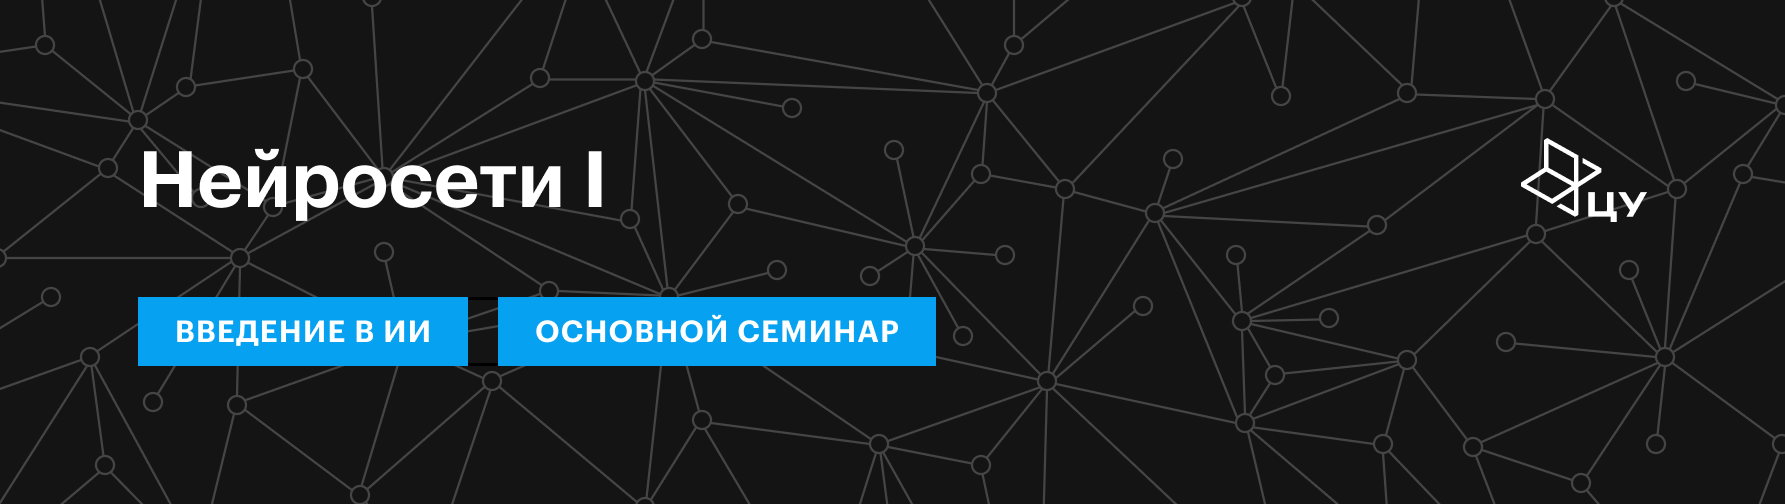

# Семинар по теме «Нейросети I»


Сегодня ты на практике разберёшь, как устроены нейросети и как их обучать.

После занятия ты сможешь:
- работать с библиотекой PyTorch,
- обучать нейросети,
- создавать нейросеть и решать задачи с её помощью.

## Тензор

Таблица — двумерная матрица: у неё есть строки и столбцы.

В работе с нейросетями у данных может быть больше измерений, чем просто строки и столбцы. Поэтому используют более общее понятие — **тензор**.

>**Тензор** — это $n$-мерная матрица, то есть обобщение привычных таблиц на произвольное число измерений.

Именно с тензорами работают нейросети.

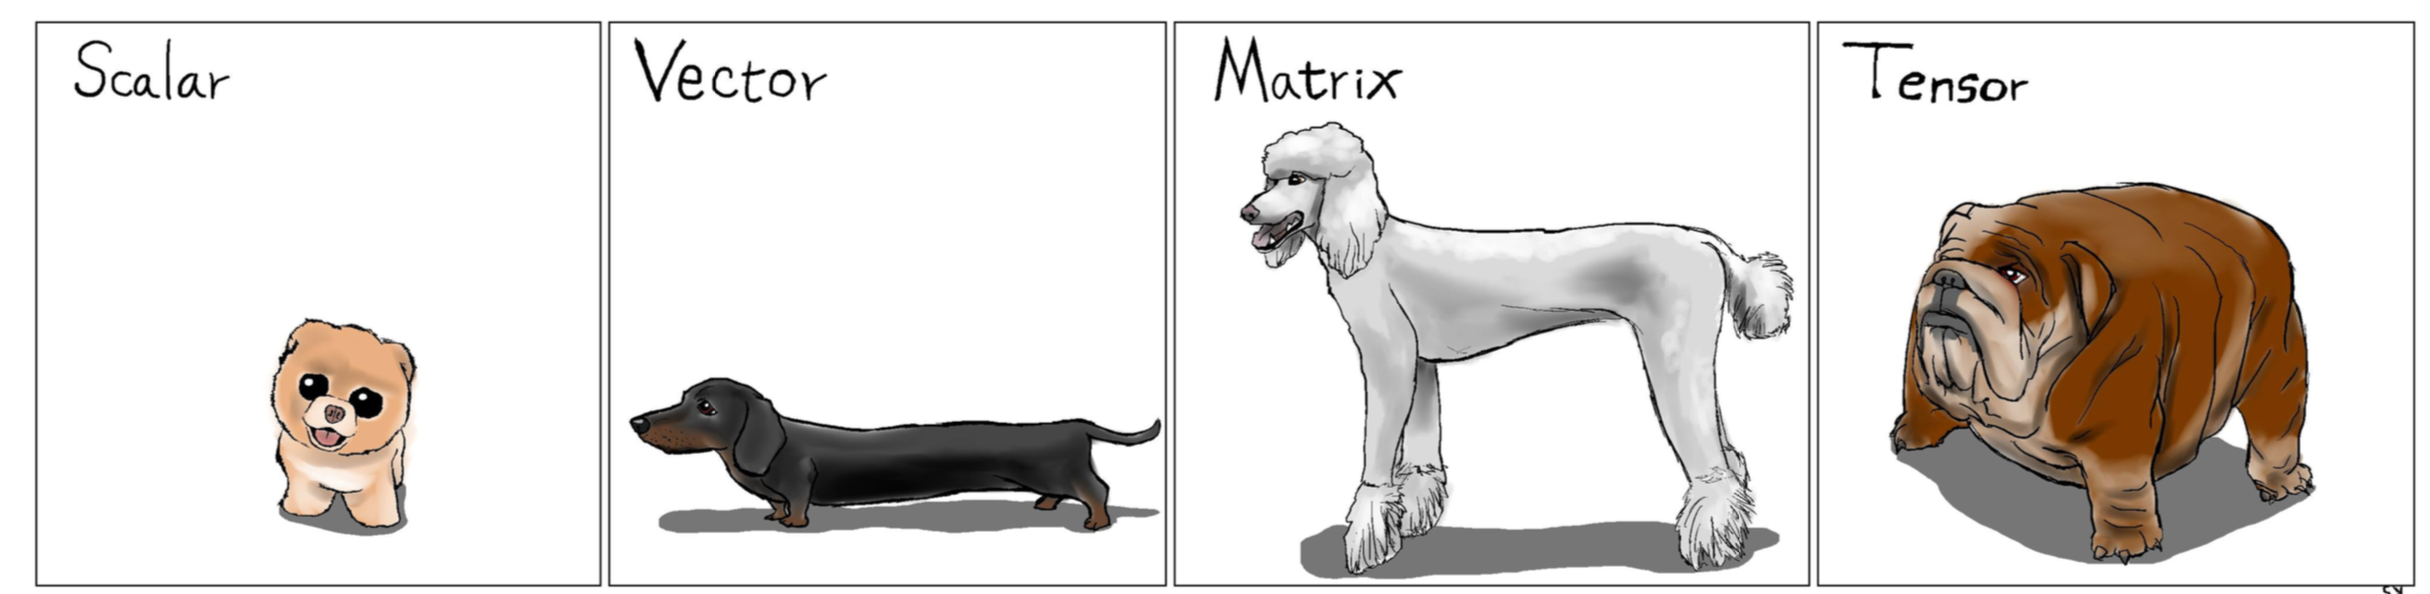


*Иллюстрация объектов разных размерностей.  [Источник изображения.](https://notebooks.githubusercontent.com/view/ipynb?browser=chrome&bypass_fastly=true&color_mode=auto&commit=270b54cd618c4045a9d04a6c0cbcb43105b665b8&device=unknown_device&docs_host=https%3A%2F%2Fdocs.github.com&enc_url=68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f6f73656c65646574732f6e6c61323032302f323730623534636436313863343034356139643034613663306362636234333130356236363562382f6c656374757265732f6c65637475726531372f6c6563747572652d31372e6970796e62&logged_in=false&nwo=oseledets%2Fnla2020&path=lectures%2Flecture17%2Flecture-17.ipynb&platform=unknown_platform&repository_id=307137783&repository_type=Repository&version=108)*

### Примеры задач

1. Входные данные — скаляр (тензор 0-го порядка).
  
   Задача: по весу человека предсказать его рост.

   Такая задача слишком простая для нейросетей: у неё всего один входной признак. В реальных сценариях входные данные почти всегда имеют большую размерность.

2. Входные данные — вектор (тензор 1-го порядка).

   Задача: по набору признаков, например площадь, количество комнат и этажей, год постройки, предсказать стоимость дачного домика.

3. Входные данные — матрица (тензор 2-го порядка).

   Задача: по чёрно-белому изображению определить, кто изображён на картинке — кошка или собака.

   В этом примере чёрный цвет может быть закодирован нулём, белый — числом 255, а градации серого — промежуточными целыми числами.

   В похожем формате можно представлять и текстовые данные. О том, как именно это делается, тебе расскажут буквально через пару недель. (˶ᵔ ᵕ ᵔ˶)

4. Входные данные — тензор 3-го и выше порядка.

   Примеры таких задач:
   * цветные изображения — это тензоры 3-го
     порядка (высота х ширина х каналы цвета);
   * видеоролики — последовательности изображений, то есть тензоры ещё большей размерности.




## PyTorch

> **PyTorch** — это библиотека для работы с тензорами и обучения нейросетей. Она поддерживает вычисления на GPU (Graphics Processing Unit, графический процессор). Часто библиотеку называют просто **torch**.

Почему для нейросетей вообще нужен отдельный инструмент? Дело в том, что нейросети почти полностью состоят из матричных операций. Такие операции хорошо выполняются параллельно. А в параллельности как раз сильны GPU:

*   у современных процессоров обычно не больше 96 ядер,
*   у GPU ядер тысячи.

Чем больше ядер, тем больше операций можно выполнять одновременно и тем быстрее обучаются нейросети. Поэтому при работе с нейросетями вычисления стараются переносить на GPU.

В NumPy тоже можно создать $n$-мерную матрицу, но эту библиотеку не используют для обучения нейросетей. Основное отличие PyTorch от NumPy — возможность выполнять матричные операции на GPU.

Благодаря поддержке GPU PyTorch стал одним из самых популярных инструментов для работы с нейросетями. Со временем в нём появился специализированный функционал для обучения моделей, которого нет в NumPy.

PyTorch поддерживает большинство операций, которые есть в NumPy и даже SciPy. Поэтому можно сказать, что это библиотека, похожая по возможностям на NumPy, но специально ориентированная на нейросети и вычисления на GPU.



Сравним работу с матрицами в NumPy и PyTorch. Создадим матрицу, выполним математические операции в двух библиотеках и проверим, совпадают ли названия операций и вывод.

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import warnings
warnings.filterwarnings("ignore")



In [3]:
# Создание матрицы
data = [[1, 2],[3, 4]]
t_data = torch.tensor(data)
np_data = np.array(data)

# Вывод совпадает
t_data, np_data

(tensor([[1, 2],
         [3, 4]]),
 array([[1, 2],
        [3, 4]]))

Попробуем математические операции.

In [4]:
# Сложение
t_data + t_data, np_data + np_data

(tensor([[2, 4],
         [6, 8]]),
 array([[2, 4],
        [6, 8]]))

In [5]:
# Поэлементное умножение
t_data * t_data, np_data * np_data

(tensor([[ 1,  4],
         [ 9, 16]]),
 array([[ 1,  4],
        [ 9, 16]]))

In [6]:
# Матричные умножения
t_data @ t_data, np_data @ np_data

(tensor([[ 7, 10],
         [15, 22]]),
 array([[ 7, 10],
        [15, 22]]))

In [7]:
# Транспонирование
t_data.T, np_data.T

(tensor([[1, 3],
         [2, 4]]),
 array([[1, 3],
        [2, 4]]))

Хотя PyTorch во многом похож на NumPy, названия некоторых операций в этих библиотеках различаются.

In [8]:
# Например, превращаем матрицу в один вектор
t_data.flatten(), np_data.ravel()

(tensor([1, 2, 3, 4]), array([1, 2, 3, 4]))

In [9]:
# Конкатенация
# Аргумент, который отвечает за названия осей в PyTorch, называется dim, а в NumPy — axis
torch.cat([t_data, t_data], dim=-1), np.concatenate([np_data, np_data], axis=-1)

(tensor([[1, 2, 1, 2],
         [3, 4, 3, 4]]),
 array([[1, 2, 1, 2],
        [3, 4, 3, 4]]))

PyTorch также поддерживает генерацию случайных чисел.

In [10]:
# Например, для равномерного распределения (но есть и все другие популярные распределения)
# Зададим ключ генерации
torch.manual_seed(123)
np.random.seed(123)

# Как мы видим, с одинаковым ключом генерация разная для двух пакетов, так как алгоритмы разные
torch.rand(size=(2, 2)), np.random.rand(2, 2)

(tensor([[0.2961, 0.5166],
         [0.2517, 0.6886]]),
 array([[0.69646919, 0.28613933],
        [0.22685145, 0.55131477]]))

Но задавать `seed` в PyTorch — не всегда хорошая идея. Это может негативно повлиять на скорость и стабильность последующего обучения. Этим надо пользоваться, только если действительно нужно.

In [11]:
# И ещё одна частая и полезная операция для преобразования формы данных
# Тоже всё работает
t_data.reshape([4, 1]), np_data.reshape([4, 1])

(tensor([[1],
         [2],
         [3],
         [4]]),
 array([[1],
        [2],
        [3],
        [4]]))

У тензоров в PyTorch можно вычислять базовые статистические показатели, например среднее значение или стандартное отклонение.


In [12]:
t_data = torch.tensor([1, 2,3, 4,0, 1,2, 0],dtype=torch.float32)

t_data.mean(dim=0, keepdim=True)

tensor([1.6250])

In [13]:
t_data = torch.tensor([[1, 2],
                     [3, 4],
                     [0, 1],
                     [2, 0]], dtype=torch.float32)

t_data.mean(dim=0, keepdim=True)

tensor([[1.5000, 1.7500]])

In [14]:
t_data = torch.tensor([[[1, 2],
              [3, 4]],
             [[0, 1],
              [2, 0]]], dtype=torch.float32)

t_data.mean(dim=0, keepdim=True)

tensor([[[0.5000, 1.5000],
         [2.5000, 2.0000]]])

In [15]:
t_data = torch.tensor([1, 2,3, 4,0, 1,2, 0],dtype=torch.float32)

t_data.std(dim=0, keepdim=True)

tensor([1.4079])

In [16]:
t_data = torch.tensor([[1, 2],[3, 4],[0, 1],[2, 0]], dtype=torch.float32)

t_data.std(dim=0, keepdim=True)

tensor([[1.2910, 1.7078]])

## Выбор среды выполнения

Мы уже говорили, что главное преимущество PyTorch — возможность выполнять вычисления на GPU. Но сейчас у нас запущена среда с CPU (Central Processing Unit), на которой PyTorch тоже умеет работать.

**Почему тогда сразу не включить GPU в Colab?**

Colab даёт бесплатный доступ к GPU лишь на ограниченное время — обычно около 3–4 часов в день, и даже это не гарантировано. Если использовать GPU для любых мелких операций, его может просто не хватить для главной задачи — обучения нейросети.

**Поэтому разумная стратегия такая:**

*   писать и отлаживать код в CPU-режиме;
*   включать GPU только тогда, когда он действительно нужен.                        

###Как включить GPU в Colab

Если для задачи всё же потребуется ускорение.

1.   Нажми «Среда выполнения» в верхнем меню.
2.   Выбери пункт «Сменить среду выполнения».

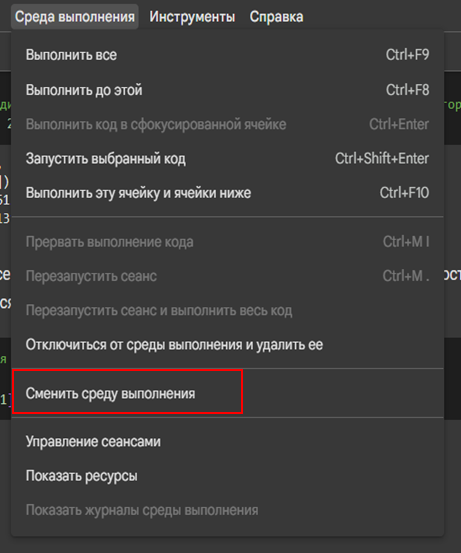

3. Выбери «Графический процессор T4». T4 — это видеокарта Nvidia, не самая новая, но за свои деньги (забесплатно) она хороша.

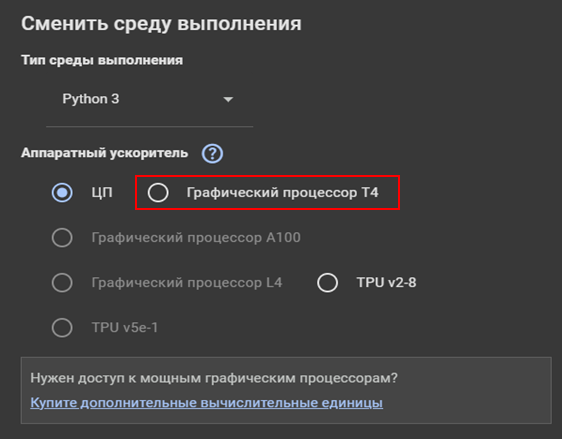

###Работа с GPU из кода

Посмотрим, как написать код для выполнения вычислений на GPU так, чтобы отличия от варианта для CPU были минимальными.

При написании нейросетей часто встречается термин **CUDA**.

> **CUDA** (Compute Unified Device Architecture)— это технология Nvidia, которая позволяет программам использовать вычислительные возможности видеокарт.


Чтобы код мог работать и на CPU, и на GPU, обычно создают переменную `device`.

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Чтобы выполнить операцию на нужном устройстве, нужно подгрузить устройство
t_data = t_data.to(device)

Теперь можно выполнять те же операции, что и раньше, но они будут происходить на выбранном устройстве.

## Пайплайн для обучения нейросети

Давай повторим этапы для обучения нейросети.

0) Постановка задачи.
1) Выбор функции потерь.
2) Предобработка данных.
3) Инициализация начальных параметров нейросети.
4) Цикл обучения:

    - Forward — вычисление ошибки при текущих параметрах;

    - Backward — вычисление градиентов для всех параметров;

    - шаг оптимизатора, изменяющий параметры.



## Оформление данных для нейросети

Разберём простую задачу классификации. Для простоты будем работать только с одной train-выборкой.

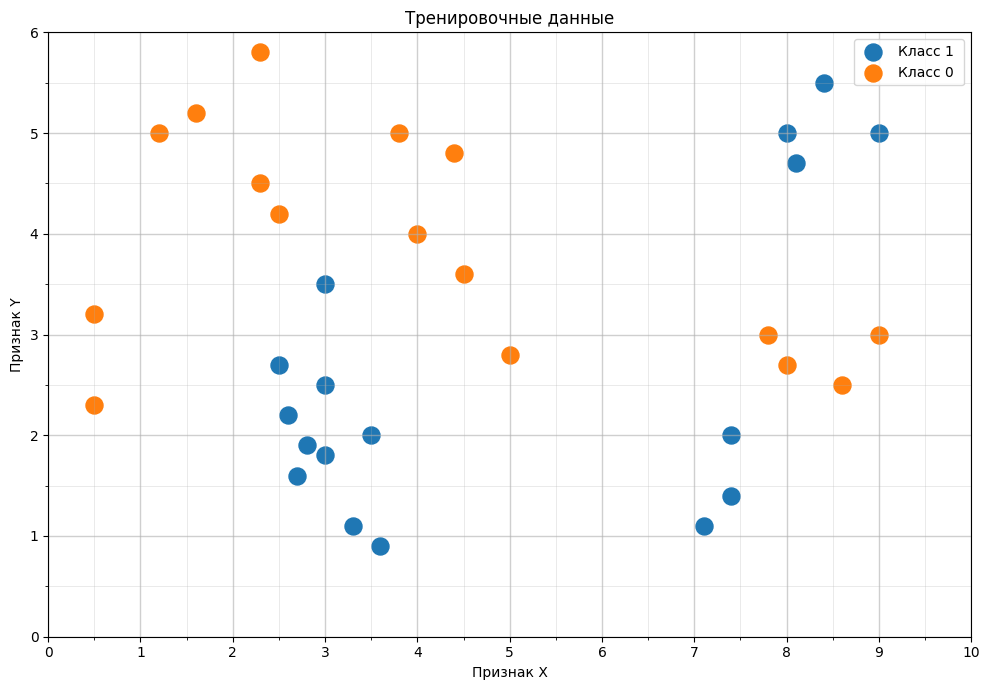

In [18]:
# Нижние точки — синие (класс 1)
x_blue = [2.6, 2.7, 3.0, 3.0, 3.3, 3.5, 3.6, 2.5, 2.8, 8.0, 8.1, 8.4, 7.4, 7.1, 7.4, 3.0, 9.0]
y_blue = [2.2, 1.6, 2.5, 1.8, 1.1, 2.0, 0.9, 2.7, 1.9, 5.0, 4.7, 5.5, 2.0, 1.1, 1.4, 3.5, 5.0]

# Верхние точки — оранжевые (класс 0)
x_orange = [0.5, 0.5, 1.2, 1.6, 2.5, 2.3, 2.3, 3.8, 4.4, 4.0, 4.5, 5.0, 7.8, 8.0, 8.6, 9.0]
y_orange = [2.3, 3.2, 5.0, 5.2, 4.2, 4.5, 5.8, 5.0, 4.8, 4.0, 3.6, 2.8, 3.0, 2.7, 2.5, 3.0]

# Соберём признаки (X_train): каждый объект — пара (x, y)
X_train = []
y_train = []

# Добавим синие точки (класс 1)
for x, y in zip(x_blue, y_blue):
    X_train.append([x, y])
    y_train.append(1)

# Добавим оранжевые точки (класс 0)
for x, y in zip(x_orange, y_orange):
    X_train.append([x, y])
    y_train.append(0)

# Преобразуем в numpy-массивы
X_train = np.array(X_train)  # Форма: (N, 2)
y_train = np.array(y_train)  # Форма: (N,)

# Визуализируем
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1 ")
ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0 ")

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

ax.grid(True, which="major", linewidth=1.0, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.6, alpha=0.3)

# Установим диапазоны
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

ax.set_xlabel("Признак X")
ax.set_ylabel("Признак Y")
ax.set_title("Тренировочные данные")
ax.legend()

plt.tight_layout()
plt.show()



Будем предсказывать вероятность того, что точка относится к синему классу.
В качестве функции потерь возьмём MSE.

Пока данные находятся в формате `numpy.array`:

In [19]:
X_train.shape, y_train.shape

((33, 2), (33,))

### Задание 1
Преобразуй `X_train` и `y_train` в тензоры `X` и `y`, а затем стандартизируй тензор `X` по столбцам — то есть нормируй каждый признак отдельно.

In [20]:
# Тензоровка
X = # Напиши код здесь
y = # Напиши код здесь


# Нормировка
X_mean =
X_std =
Xn = X - # Напиши код здесь


# Приведение к типу float
X = X.float()
y = y.float()
X_mean = X_mean.float()
X_std = X_std.float()
Xn = Xn.float()

print(f"Было:  {X.mean(dim=0), X.std(dim=0)}")
print(f"Стало: {Xn.mean(dim=0), Xn.std(dim=0)}")

SyntaxError: invalid syntax (ipython-input-2671422943.py, line 2)


### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [21]:
# Тензоровка
X = torch.tensor(X_train)
y = torch.tensor(y_train)

# Нормировка (желательно)
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True) + 1e-8
Xn = (X - X_mean) / X_std

# Приведение к типу float
X = X.float()
y = y.float()
X_mean = X_mean.float()
X_std = X_std.float()
Xn = Xn.float()

print(f"Было:  {X.mean(dim=0), X.std(dim=0)}")
print(f"Стало: {Xn.mean(dim=0), Xn.std(dim=0)}")

Было:  (tensor([4.5879, 3.2273]), tensor([2.7037, 1.4507]))
Стало: (tensor([3.6124e-09, 0.0000e+00]), tensor([1., 1.]))


## Введение в ООП

Возможно, ты уже знаешь это понятие. Разберём основы объектно-ориентированного программирования (ООП), которые понадобятся для написания нейросетей.

**Объектно‑ориентированное программирование (ООП)** — это особый подход к написанию кода, при котором создаются наборы «объектов» — самостоятельных сущностей с данными и поведением. Они «общаются» между собой и выполняют задачи.

В Python эти наборы называются классами. Давай разберём простой пример класса.


In [22]:
class Animal:
    def __init__(self, energy=5): # Очень важный метод, он инициализирует начальное состояние класса. Без него нам не обойтись
        """
        Конструктор класса.
        :param energy: начальное значение энергии (по умолчанию 5)
        """
        self.energy = energy  # int: уровень энергии
        self.alive = True      # bool: жив ли объект

    def voice(self):
        """
        Метод издаёт звук "РЁВ" и уменьшает энергию на 1.
        Если энергия = 0, животное умирает (alive = False).
        Если животное мертво, выводит только "Death :("
        """
        if not self.alive: # Если животное мертво, то сообщаем об этом
            print("Death :(")
            return

        print("РЁВ")
        self.energy -= 1

        if self.energy <= 0:
            self.alive = False # Если животное потратило последнюю энергию, то оно умирает

    def eat(self):
        """
        Метод имитирует приём пищи: выводит "ХРУМ-ХРУМ" и увеличивает энергию на 1.
        Если животное мертво, выводит только "Death :("
        """
        if not self.alive:
            print("Death :(")
            return

        print("ХРУМ-ХРУМ")
        self.energy += 1


Посмотрим, как создать экземпляр класса и воспользоваться им.

In [23]:
a_1 = Animal(2)

a_1.voice()
a_1.voice()
a_1.voice()
a_1.voice()

РЁВ
РЁВ
Death :(
Death :(


Первое животное слишком много рычало и забыло о еде ;(

In [24]:
a_2 = Animal(3)

a_2.voice()
a_2.voice()

a_2.eat()
a_2.eat()

a_2.voice()
a_2.voice()

РЁВ
РЁВ
ХРУМ-ХРУМ
ХРУМ-ХРУМ
РЁВ
РЁВ


Итак, мы создали класс `Animal`, чтобы объекты имели общий набор свойств. Но животных много, и у каждого вида есть свои особенности.

Как сохранить общий механизм выживания (есть энергия, и при её исчерпании животное умирает), не переписывая код заново и не копируя его вручную?

В этом нам поможет наследование!

**Наследование в ООП** — это механизм, позволяющий создавать новые классы на основе уже существующих, добавляя свои методы или переопределяя логику родительского класса.

In [25]:
class Dog(Animal):
    def voice(self): # Переопределение метода
        if not self.alive:
            print("Death :(")
            return
        print("ГАВ-ГАВ")
        self.energy -= 1
        if self.energy <= 0:
            self.alive = False

In [26]:
class Bear(Animal):
    def sleep(self): # Добавление нового метода
        if not self.alive:
            print("Death :(")
            return
        print("Медведь спит...")
        self.energy += 5
        print(f"Энергия восстановлена! Текущая энергия: {self.energy}")


In [27]:
# Создаём собаку
dog = Dog(energy=3)
dog.voice()  # Выведет: ГАВ-ГАВ (energy=2)
dog.voice()  # Выведет: ГАВ-ГАВ (energy=1)
dog.voice()  # Выведет: ГАВ-ГАВ (energy=0, alive=False)
dog.voice()  # Выведет: Death :(

ГАВ-ГАВ
ГАВ-ГАВ
ГАВ-ГАВ
Death :(


In [28]:
# Создаём медведя
bear = Bear(energy=2)
bear.sleep()  # Выведет: Медведь спит... Энергия восстановлена! Текущая энергия: 7
bear.voice() # Выведет: РЁВ (energy=6) — использует оригинальный метод Animal


Медведь спит...
Энергия восстановлена! Текущая энергия: 7
РЁВ


В ООП существует множество подходов и техник: различные способы проектирования классов, наследование, паттерны программирования. Однако сейчас тебе достаточно базовых знаний — их хватит, чтобы понять, как PyTorch позволяет создавать нейросети.

## Создание нейросети

Перед тем как писать первую нейросеть, разберём синтаксис на примере нейросети `ExampleNet`. В PyTorch нейросеть описывается как отдельный класс, который наследуется от `nn.Module`. Это позволяет библиотеке корректно работать с нашей сетью: обучать её, сохранять параметры и объединять с другими модулями.

В PyTorch уже есть готовые строительные блоки для нейросетей:

- обычный полносвязный слой: `nn.Linear(in_features, out_features)`;

- функции активации, например `nn.ReLu()` или `nn.Tanh()`.


Наши первые нейросети будут содержать только полносвязные блоки и нелинейности — это один из самых простых вариантов архитектуры.

Чтобы создать свою нейросеть, нужно реализовать два метода.
1. `__init__` — задаёт слои и параметры сети.
2. `forward` — описывает, как данные проходят через сеть.

In [29]:
import torch.nn as nn

# Пример нейросети
class ExampleNet(nn.Module):

  def __init__(self):
    super().__init__() # Инициаилзируем не только параметры сети, но и модуль в PyTorch

    # Sequential — контейнер для последовательного соединения слоёв
    # Линейный слой —> ReLU —> Линейный слой —> и так далее
    self.net = nn.Sequential(
        nn.Linear(in_features=10, out_features=20), # in_features — количество фичей на входе в блок; out_features — количество фичей на выходе из блока. bias=True по умолчанию (добавлять ли константу смещения)
        nn.ReLU(),
        nn.Linear(20, 14),
        nn.ReLU(),
        nn.Linear(14, 1) # Выход размерности 1
    )

  def forward(self, X):
    return self.net(X)

In [32]:
# Альтернативный вариант — объявить слои нейросети как отдельные атрибуты класса

class ExampleNet(nn.Module):
    def __init__(self):
        super().__init__()  # Обязательный вызов родителя

        self.fc1 = nn.Linear(10, 20)   # Первый полносвязный слой
        self.relu1 = nn.ReLU()            # Активация после первого слоя
        self.fc2 = nn.Linear(20, 14)  # Второй полносвязный слой
        self.relu2 = nn.ReLU()            # Активация после второго слоя
        self.fc3 = nn.Linear(14, 1)   # Выходной слой (1 выход)

    def forward(self, x):
        # Прямой проход: данные текут через слои последовательно
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)  # Одномерный выход
        return x


Убедимся, что нейросеть работает. Сеть ожидает на вход 10 чисел, поэтому создадим тензор из 10 элементов и передадим его в модель.

In [33]:
data = np.arange(10)
t_data = torch.tensor(data, dtype=torch.float32)

net = ExampleNet()
net(t_data)

tensor([0.7757], grad_fn=<ViewBackward0>)

Нейросеть действительно пропустила через себя данные и выдала ответ! Правда, без её обучения пользы от этого ответа мало.

Теперь, когда понятен базовый синтаксис, можно перейти к созданию собственной нейросети.

### Задание 2

Напиши первую нейросеть. Пусть в ней будет:

- входной слой из 4 нейронов с функцией активации ReLU;
- выходной слой из 1 нейрона — это выход нейросети, к нему примени сигмоиду, чтобы получить вероятность.

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Напиши код здесь
    def forward(self, x):

        return p

In [ ]:
# Тест
data = np.arange(2)
t_data = torch.tensor(data, dtype=torch.float32)

net = TinyNet()
net(t_data)

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.fc1(x))
        p = self.sigmoid(self.out(x))   # вероятность в (0,1)
        return p

In [ ]:
# Тест
data = np.arange(2)
t_data = torch.tensor(data, dtype=torch.float32)

net = TinyNet()
net(t_data)

tensor([0.4833], grad_fn=<SigmoidBackward0>)

На лекции в примерах мы использовали функцию знака. Она очень хороша тем, что позволяет просто интерпретировать, к какому классу относится объект.  
Почему бы не добавить её в нашу нейросеть?

In [ ]:
relu = nn.ReLU()

relu(torch.tensor([1,0,-1]))

tensor([1, 0, 0])

In [ ]:
sgn = nn.Sgn()

sgn(torch.tensor([1,0,-1]))

AttributeError: module 'torch.nn' has no attribute 'Sgn'

Дело в том, что функции `Sgn` в в PyTorch просто нету.

Почему разработчики PyTorch не добавили такую, казалось бы, простую функцию активации?

Причина простая. Производная функции знака либо равна 0, либо не определена в 0. В таком случае градиентный спуск не работает, потому что градиенты либо исчезают, либо не существуют. Поэтому эту функцию не используют при обучении нейросетей.

Но отказываться от ступеньки необязательно.
Можно присмотреться к другой функции активации - к гиперболическому тангенсу. Он ведёт себя похоже: значения лежат в диапазоне от -1 до 1, а график напоминает ступеньку

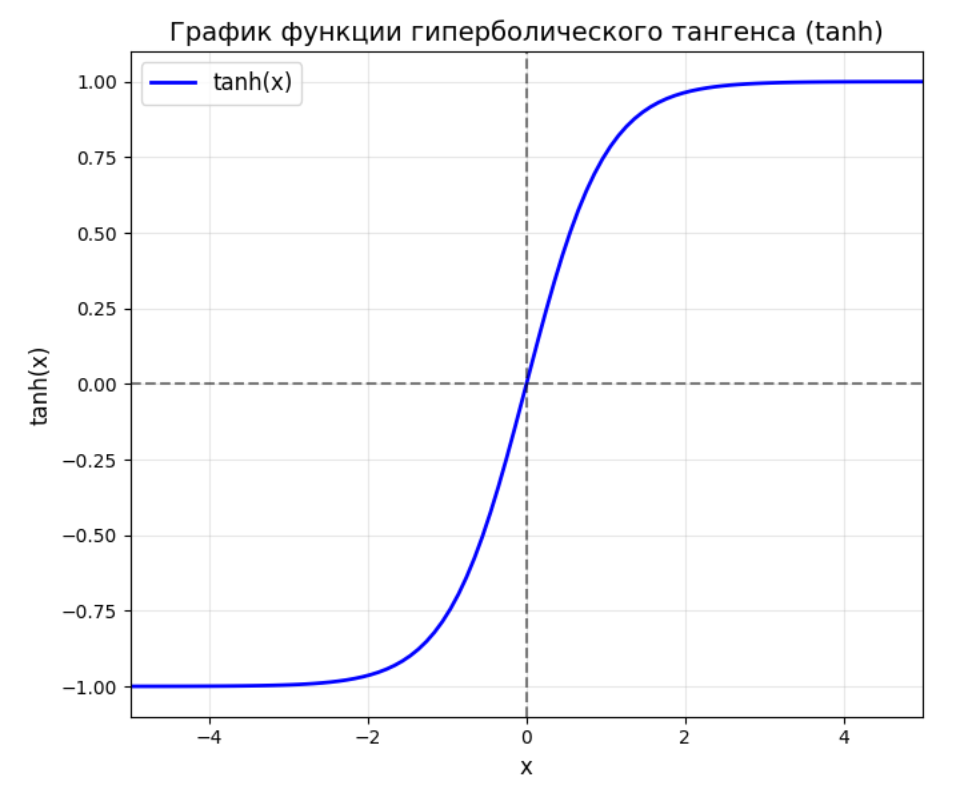

Если подавать в тангенс не просто `x`, а, например `10x`, то будет еще круче!

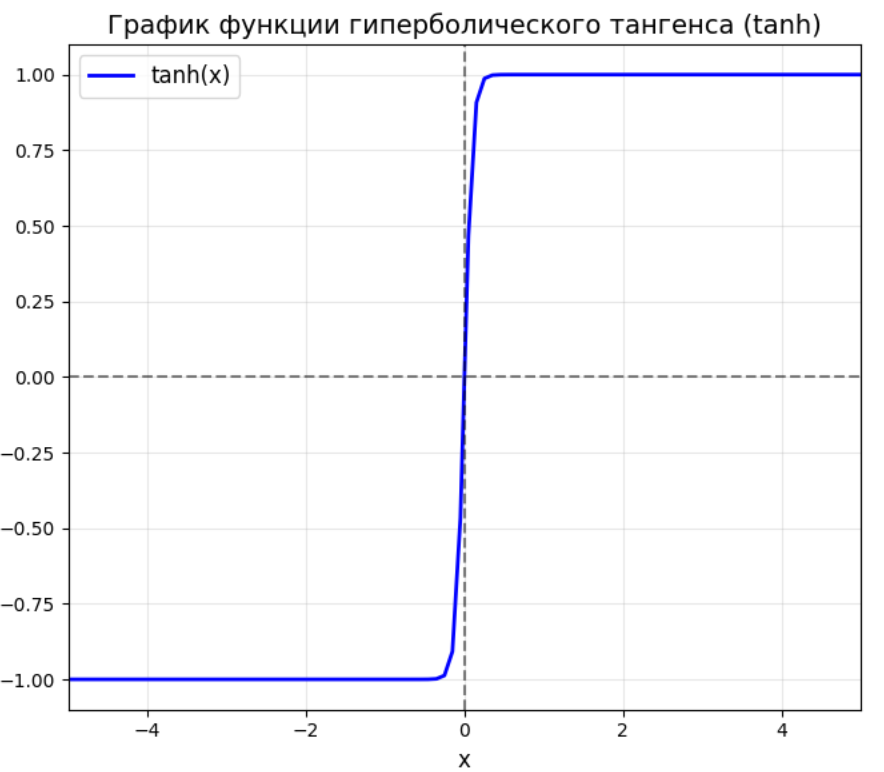

### Задание 3

Замени функцию активации на `nn.Tanh()` и передай туда не `x`, а `5x`. Так функция больше похожа на ступеньку, и при этом есть достаточно большой участок, где производная ненулевая.

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Твой код

    def forward(self, x):

        return p

In [ ]:
# Тест
data = np.arange(2)
t_data = torch.tensor(data, dtype=torch.float32)

net = TinyNet()
net(t_data)

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(5.0 * self.fc1(x))
        p = self.sigmoid(self.out(x))   # вероятность в (0,1)
        return p

In [ ]:
# Тест
data = np.arange(2)
t_data = torch.tensor(data, dtype=torch.float32)

net = TinyNet()
net(t_data)

tensor([0.6926], grad_fn=<SigmoidBackward0>)

## Обучение модели: градиентный спуск

Определим модель, функционал ошибки и оптимизатор.

In [ ]:
model = TinyNet()

criterion = nn.MSELoss()
# Передаём оптимизатору параметры модели — именно их он будет обновлять
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

Дальше нужна функция, которая делает шаг градиентного спуска.

In [ ]:
# Функция для расчёта метрик
@torch.no_grad()
def compute_metrics():
    model.eval()
    probs = model(Xn)                    # (N,1)
    loss = criterion(probs, y).item()
    preds = (probs >= 0.5).float()
    acc = (preds.eq(y)).float().mean().item()
    return loss, acc

**ВАЖНО:** декоратор `@torch.no_grad()` означает, что действия, вычисляемые в этой функции, не относятся к основному циклу обучения и не должны учитываться при подсчёте градиентов. Если бы no_grad не было, замедлилась бы работа и расходовалось больше  памяти.

In [ ]:
# Функция, которая делает один шаг градиентного спуска

def train_step():

    model.train() # Переводим нейросеть в режим обучения

    optimizer.zero_grad() # Обнуляем накопившиеся градиенты

    probs = model(Xn)                 # (N,1)
    loss = criterion(probs, y)        # MSE по вероятностям

    loss.backward() # Вычисляем градиенты функции потерь по параметрам модели
    optimizer.step() # Делаем шаг

    return compute_metrics() # Возвращаем метрики




Следующая функция рисует поле вероятностей. Мы будем использовать её, когда потребуется увидеть текущее состояние поля вероятностей.

In [ ]:
@torch.no_grad()
def plot_data_and_boundary():
    model.eval()

    x_min, x_max = 0, 10
    y_min, y_max = 0, 6
    grid_n = 150

    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    grid_t = torch.tensor(grid)

    # Нормируем так же, как обучающие данные
    grid_tn = (grid_t - X_mean) / X_std

    probs = model(grid_tn).reshape(grid_n, grid_n).cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 7))

    cf = ax.contourf(Xg, Yg, probs, levels=30, alpha=0.35)
    plt.colorbar(cf, ax=ax, label="P(class=1)")

    # Рисуем границу решений: p = 0.5
    ax.contour(Xg, Yg, probs, levels=[0.5], linewidths=2)

    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1")
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0")

    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))

    ax.grid(True, which="major", linewidth=1.0, alpha=0.6)
    ax.grid(True, which="minor", linewidth=0.6, alpha=0.3)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.set_title("Данные и граница решения")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Рубрика «Э-э-эксперименты!»

In [ ]:
# @title
# Определения

# Виджеты для пошагового градиентного спуска

SEED = 264

# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn

CUSTOM_INIT_STATE = None


def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


LR = 0.2
criterion = nn.MSELoss()
_state = {"step": 0}

# -----------------------------
# Настройки скорости/детализации
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1

N_LEVELS = 25  # Промежуточные линии

# Окно отображения
X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0

# Палитра
CMAP = "viridis"

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer
    _seed_everything(seed)
    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

# -----------------------------
# Сетка (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

def predict_prob_grid():
    device = next(model.parameters()).device if any(True for _ in model.parameters()) else "cpu"
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    model.eval()
    with torch.no_grad():
        grid_t = torch.from_numpy(grid).to(device)
        grid_tn = (grid_t - xm) / xs_
        probs = model(grid_tn).view(-1).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    # На всякий случай, если сеть выдала почти константу
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()

    # Динамический диапазон
    vmin = float(np.nanmin(P))
    vmax = float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1) Фон — imshow
    im = ax.imshow(
        P,
        origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax
    )

    # 2) Промежуточные линии уровня
    ax.contour(
        Xg, Yg, P,
        levels=levels,
        colors="black",
        alpha=0.25,
        linewidths=0.8,
        zorder=2
    )

    # 3) Граница решения: p = 0.5
    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    # 4) Точки
    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    # 5) Цветовая шкала справа с min/max
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    # 6) Оформление
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    # Строка со статистикой шага
    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)


### Задание 4

Напиши код, который:

*   делает один шаг обучения нейросети (один шаг градиентного спуска);
*   выводит текущую границу решения с помощью `plot_data_and_boundary`.

Запусти этот код несколько раз и посмотри, как меняется граница решения после каждого шага.

In [ ]:
SEED = 264

# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость
torch.use_deterministic_algorithms(True)


In [ ]:
# Напиши код здесь

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

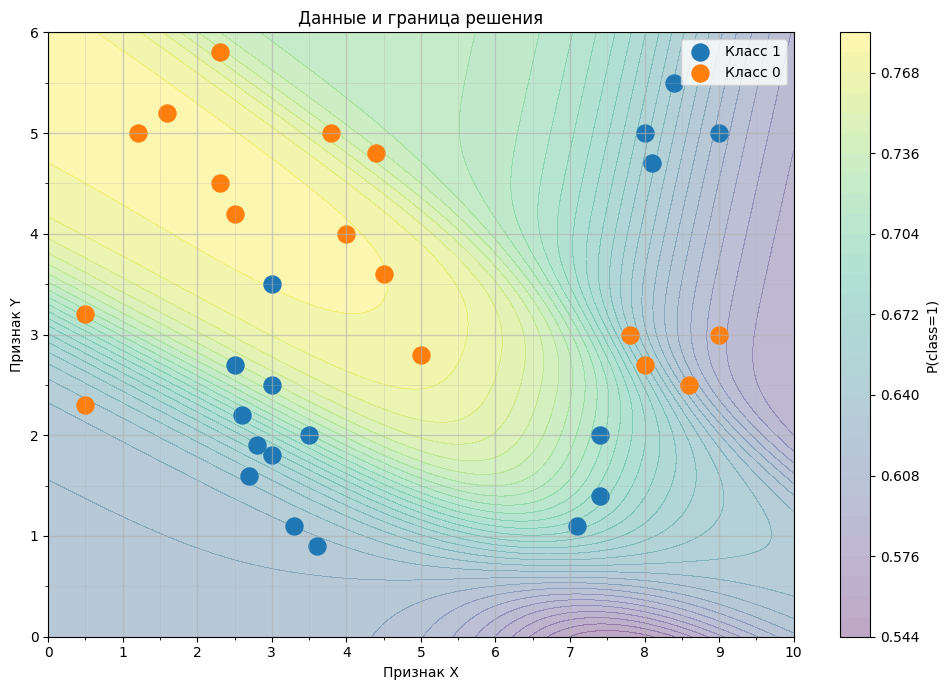

In [ ]:
loss, acc = train_step()

plot_data_and_boundary()


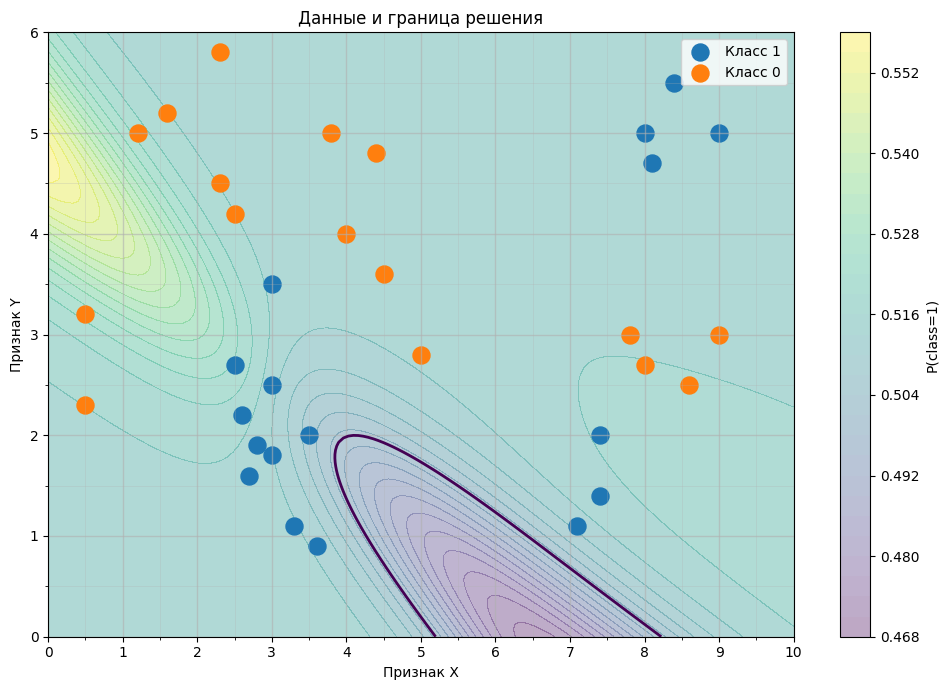

In [ ]:
#  Делаем несколько шагов обучения подряд

for i in range(100):
  loss, acc = train_step()


plot_data_and_boundary()

## Визуализация границы решения

Ниже используется скрытый код для визуализации. Он делает то же самое, что и `plot_data_and_boundary`. При помощи него мы можем последовательно выполнять шаги градиентного спуска.

In [ ]:
# @title
display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)

Output()

### Задание 5

Учитывая выбранную функцию активации, предположи, как нейросеть принимает решение. На что будет похожа граница между классами?


### ОТВЕТ ДЛЯ СЕМИНАРИСТА

4 нейрона должны задавать прямые линии, а итог должен суммироваться и преобразовываться в вероятность

Убедимся в наших предположениях и рассмотрим их наглядно.

Из обученной нейросети мы можем достать её параметры

In [ ]:
def print_model_summary_and_weights(model):
    print("=== Архитектура модели ===")
    print(model)

    print("\n=== Параметры (веса и смещения) ===")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            W = module.weight.detach().cpu().numpy()
            b = module.bias.detach().cpu().numpy()
            print(f"\n[{name}] Linear(in={module.in_features}, out={module.out_features})")
            print("W =")
            print(np.array2string(W, precision=4, suppress_small=True))
            print("b =")
            print(np.array2string(b, precision=4, suppress_small=True))



print_model_summary_and_weights(model)

=== Архитектура модели ===
TinyNet(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (out): Linear(in_features=4, out_features=1, bias=True)
  (act): Tanh()
  (sigmoid): Sigmoid()
)

=== Параметры (веса и смещения) ===

[fc1] Linear(in=2, out=4)
W =
[[ 0.3896  0.6979]
 [ 0.5406  0.7021]
 [ 0.1546  0.1489]
 [-0.5694 -0.1313]]
b =
[ 0.3065  0.2222  0.5189 -0.2802]

[fc2] Linear(in=4, out=4)
W =
[[-0.034  -0.2146 -0.4895  0.4645]
 [-0.3987  0.0218  0.255   0.2961]
 [-0.0203 -0.199   0.2948 -0.3795]
 [ 0.3987  0.3304 -0.4899 -0.1388]]
b =
[ 0.3254  0.3158  0.3621 -0.309 ]

[out] Linear(in=4, out=1)
W =
[[-0.0258 -0.1864  0.3495 -0.13  ]]
b =
[-0.1351]


Если бы наши данные не преобразовывались, (мы их стандартизировали) то мы бы увидели прямую $w_1x+w_2y+b=0$.

Чтобы учесть эффект масштаба нужно поделить признаки $w_1 и w_2$ на соответствующие стандартные отклонения (они есть у нас в `X_std`)

Свободный член преобразуется так:

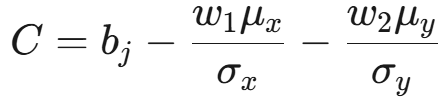

In [ ]:
X_mean

tensor([[4.5879, 3.2273]])

In [ ]:
X_std

tensor([[2.7037, 1.4507]])

Данные факты нетрудно обосновать строго

Так как нейросеть работает с нормированными данными, то мы можем записать внутренность нейрона (линейная модель) следующим образом:


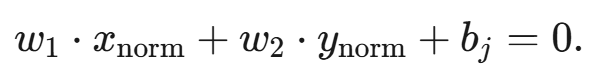

Но мы помним, что в нейросеть мы подаем нормированные признаки, получившиеся из обычных признаков вычитанием среднего и делением на стандартное отклонение.

Подставим формулу в наше уравнение и вскроем скобки:

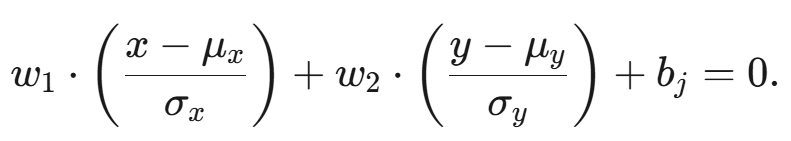

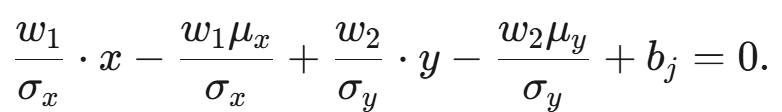

Отсюда видно, что коэффициенты $A$ $B$ $C$ в уравнении $Ax+By+C=0$ точно такие, как мы писали ранее

Отрисуем красиво все 4 прямые:

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import torch
import torch.nn as nn

@torch.no_grad()
def plot_points_and_fc1_lines(
    model: nn.Module,
    x_blue, y_blue,
    x_orange, y_orange,
    X_mean=None, X_std=None,          # если вход нормировался: (X - mean)/std
    xlim=(0, 10), ylim=(0, 6),
    title="Точки и прямые 1-го слоя (fc1)",
    show_fill=False,
    grid_n=300,
):

    model.eval()

    # достаем веса fc1
    fc1 = model.fc1
    W = fc1.weight.detach().cpu().numpy()  # shape (out, in) = (m,2)
    b = fc1.bias.detach().cpu().numpy()    # shape (m,)

    fig, ax = plt.subplots(figsize=(10, 7))

    # Фон вероятностей модели
    if show_fill:
        xs = np.linspace(xlim[0], xlim[1], grid_n, dtype=np.float32)
        ys = np.linspace(ylim[0], ylim[1], grid_n, dtype=np.float32)
        Xg, Yg = np.meshgrid(xs, ys)
        grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
        grid_t = torch.tensor(grid)

        if (X_mean is not None) and (X_std is not None):
            grid_t = (grid_t - X_mean) / X_std

        probs = model(grid_t).reshape(grid_n, grid_n).cpu().numpy()
        cf = ax.contourf(Xg, Yg, probs, levels=30, alpha=0.25)
        plt.colorbar(cf, ax=ax, label="P(class=1)")

    # точки
    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1")
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0")

    # рисуем прямые для каждого нейрона fc1
    xs = np.linspace(xlim[0], xlim[1], 500, dtype=np.float32)

    for j in range(W.shape[0]):
        w1, w2 = W[j, 0], W[j, 1]
        bj = b[j]

        # Если была нормировка входа: x_norm = (x - mean)/std,
        # то уравнение прямой в исходных координатах меняется.
        #
        # s = w1*((x-mx)/sx) + w2*((y-my)/sy) + b = 0
        # => (w1/sx)*x + (w2/sy)*y + (b - w1*mx/sx - w2*my/sy) = 0
        if (X_mean is not None) and (X_std is not None):
            mx, my = float(X_mean[0, 0].cpu()), float(X_mean[0, 1].cpu())
            sx, sy = float(X_std[0, 0].cpu()), float(X_std[0, 1].cpu())

            A = w1 / sx
            B = w2 / sy
            C = bj - w1 * mx / sx - w2 * my / sy
        else:
            A, B, C = w1, w2, bj

        # A*x + B*y + C = 0 -> y = -(A*x + C)/B
        # если B≈0 -> вертикальная линия x = -C/A
        eps = 1e-12
        if abs(B) > eps:
            ys = -(A * xs + C) / B
            ax.plot(xs, ys, linewidth=2, label=f"$fc1$ neuron {j}: ${A:.3f}x + {B:.3f}y + {C:.3f} = 0$")
            # ax.plot(xs, ys, linewidth=2, label=f"fc1 neuron {j}: A x + B y + C = 0")
        else:
            if abs(A) > eps:
                x0 = -C / A
                ax.axvline(x=x0, linewidth=2, label=f"fc1 neuron {j}: x = {x0:.2f}")

    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))

    ax.grid(True, which="major", linewidth=1.0, alpha=0.6)
    ax.grid(True, which="minor", linewidth=0.6, alpha=0.3)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

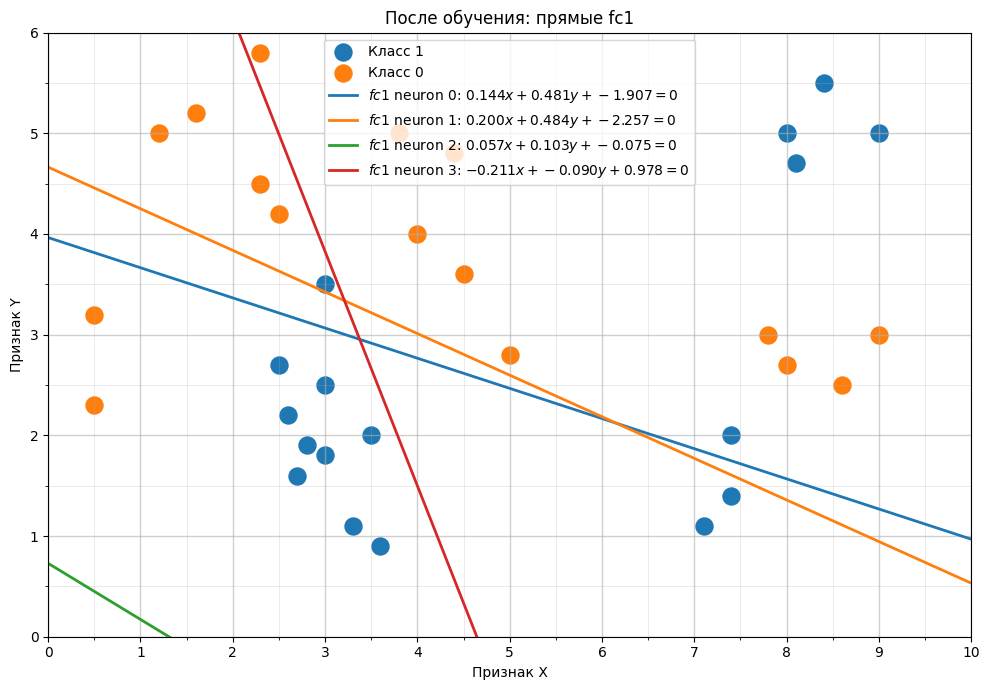

In [ ]:
plot_points_and_fc1_lines(
    model,
    x_blue, y_blue,
    x_orange, y_orange,
    X_mean=X_mean, X_std=X_std,
    title="После обучения: прямые fc1"
)

Если вспомнить карту вероятностей, то можно заметить, что граница реально "склеивается" из прямых. Гладкой она получается благодаря непрерывной и дифференцируемой функции активации.

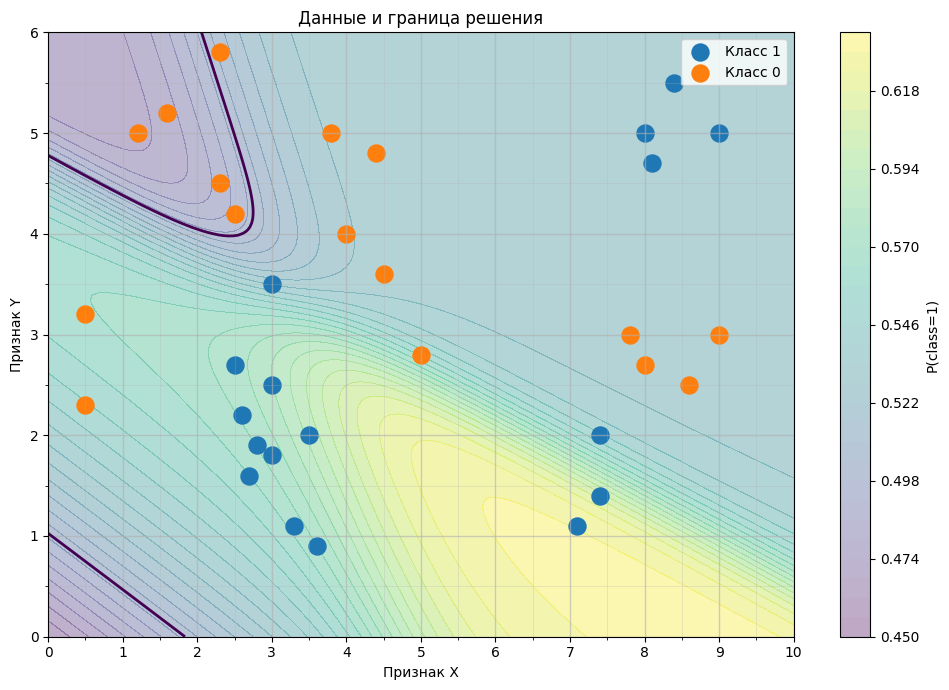

In [ ]:
plot_data_and_boundary()

### Задание 6

Что изменится, если сделать функцию активации ближе к пороговой?

Перепиши `TinyNet` и обучи нейросеть: сделай несколько десятков шагов градиентного спуска. Затем объясни, что происходит с границей решения и почему.


In [ ]:
# Напиши код здесь

In [ ]:
SEED = 100

In [ ]:
# @title
# Виджеты для плавного пошагового градиентного спуска


# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость (может замедлять, но зато детерминизм)
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn


CUSTOM_INIT_STATE = None


def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


LR = 0.2
criterion = nn.MSELoss()
_state = {"step": 0}

# -----------------------------
# Настройки скорости/детализации
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1


N_LEVELS = 25               # Промежуточные линии

# Окно отображения
X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0

# Палитра
CMAP = "viridis"

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer
    _seed_everything(seed)
    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

# -----------------------------
# Сетка (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

def predict_prob_grid():
    device = next(model.parameters()).device if any(True for _ in model.parameters()) else "cpu"
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    model.eval()
    with torch.no_grad():
        grid_t = torch.from_numpy(grid).to(device)
        grid_tn = (grid_t - xm) / xs_
        probs = model(grid_tn).view(-1).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    # На всякий случай, если сеть выдала почти константу
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()

    # Динамический диапазон
    vmin = float(np.nanmin(P))
    vmax = float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1) Фон — imshow
    im = ax.imshow(
        P,
        origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax
    )

    # 2) Промежуточные линии уровня
    ax.contour(
        Xg, Yg, P,
        levels=levels,
        colors="black",
        alpha=0.25,
        linewidths=0.8,
        zorder=2
    )

    # 3) Граница решения: p = 0.5
    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    # 4) Точки
    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    # 5) Цветовая шкала справа с min/max
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    # 6) Оформление
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    # Строка со статистикой шага
    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)


Output()

In [ ]:
# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость (может замедлять, но зато детерминизм)
torch.use_deterministic_algorithms(True)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)


Output()

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module): # Тут что то нужно поменять
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(50.0 * self.fc1(x))
        p = self.sigmoid(self.out(x))   # вероятность в (0,1)
        return p

Граница решения становится резче: вместо плавного перехода появляются почти прямые линии, сглаживание остаётся, но оно небольшое.

Обучение идёт рывками: иногда граница почти не меняется, а иногда за один шаг заметно скачет. Причина в производной `tanh(50x)`: на большинстве значений она близка к нулю, и градиенты почти исчезают. А в узкой зоне перехода производная становится большой - поэтому изменения получаются резкими.

### Задание 7

Что изменится, если добавить ещё один слой?

Перепиши `TinyNet()`, верни прежнюю настройку функции активации и обучи модель по шагам. Затем объясни, как изменилась граница решения.


In [ ]:
class TinyNet(nn.Module): # Тут что-то нужно поменять
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(20.0 * self.fc1(x))
        p = self.sigmoid(self.out(x))   # Вероятность в (0,1)
        return p

In [ ]:
SEED = 1906

In [ ]:
# @title
# Виджеты для плавного пошагового градиентного спуска


# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость (может замедлять, но зато детерминизм)
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn


CUSTOM_INIT_STATE = None


def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


LR = 0.2
criterion = nn.MSELoss()
_state = {"step": 0}

# -----------------------------
# Настройки скорости/детализации
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1


N_LEVELS = 25               # Промежуточные линии

# Окно отображения
X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0

# Палитра
CMAP = "viridis"

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer
    _seed_everything(seed)
    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

# -----------------------------
# Сетка (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

def predict_prob_grid():
    device = next(model.parameters()).device if any(True for _ in model.parameters()) else "cpu"
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    model.eval()
    with torch.no_grad():
        grid_t = torch.from_numpy(grid).to(device)
        grid_tn = (grid_t - xm) / xs_
        probs = model(grid_tn).view(-1).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    # На всякий случай, если сеть выдала почти константу
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()

    # Динамический диапазон
    vmin = float(np.nanmin(P))
    vmax = float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1) Фон — imshow
    im = ax.imshow(
        P,
        origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax
    )

    # 2) Промежуточные линии уровня
    ax.contour(
        Xg, Yg, P,
        levels=levels,
        colors="black",
        alpha=0.25,
        linewidths=0.8,
        zorder=2
    )

    # 3) Граница решения: p = 0.5
    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    # 4) Точки
    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    # 5) Цветовая шкала справа с min/max
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    # 6) Оформление
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    # Строка со статистикой шага
    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)


Output()

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(5.0 * self.fc1(x))
        x = self.act(5.0 * self.fc2(x))
        p = self.sigmoid(self.out(x))   # вероятность в (0,1)
        return p

Модель усложнилась, поэтому граница решения стало более изогнутой

### Задание 8

Добавим больше слоёв!

Перепиши код `TinyNet()`, добавив ещё 2 таких же линейных слоя, и обучи нейронку по шагам.

Затем объясни, как изменилась граница решения и почему.


In [ ]:
# Напиши код здесь

In [ ]:
SEED = 1906


In [ ]:
# @title
# Виджеты для плавного пошагового градиентного спуска


# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU + GPU)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость (может замедлять, но зато детерминизм)
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn


CUSTOM_INIT_STATE = None


def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


LR = 0.2
criterion = nn.MSELoss()
_state = {"step": 0}

# -----------------------------
# Настройки скорости/детализации
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1


N_LEVELS = 25               # Промежуточные линии

# Окно отображения
X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0

# Палитра
CMAP = "viridis"

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer
    _seed_everything(seed)
    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

# -----------------------------
# Сетка (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

def predict_prob_grid():
    device = next(model.parameters()).device if any(True for _ in model.parameters()) else "cpu"
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    model.eval()
    with torch.no_grad():
        grid_t = torch.from_numpy(grid).to(device)
        grid_tn = (grid_t - xm) / xs_
        probs = model(grid_tn).view(-1).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    # На всякий случай, если сеть выдала почти константу
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()

    # Динамический диапазон
    vmin = float(np.nanmin(P))
    vmax = float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1) Фон — imshow
    im = ax.imshow(
        P,
        origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax
    )

    # 2) Промежуточные линии уровня
    ax.contour(
        Xg, Yg, P,
        levels=levels,
        colors="black",
        alpha=0.25,
        linewidths=0.8,
        zorder=2
    )

    # 3) Граница решения: p = 0.5
    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    # 4) Точки
    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    # 5) Цветовая шкала справа с min/max
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    # 6) Оформление
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    # Строка со статистикой шага
    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)


Output()

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(5.0 * self.fc1(x))
        x = self.act(5.0 * self.fc2(x))
        x = self.act(5.0 * self.fc2(x))
        x = self.act(5.0 * self.fc2(x))
        p = self.sigmoid(self.out(x))   # вероятность в (0,1)
        return p

Нейросеть опирается всего на 4 прямые. Дальше она комбинирует области, которые эти прямые задают. Результат лучше, чем раньше, но четырёх прямых всё равно недостаточно, чтобы точно разделить классы.

### Почему модель застревает при обучении

Посмотрим внимательнее на полученные результаты.

Мы построили несколько моделей и подметили, как особенности их архитектуры повлияли на поля вероятностей. Но одно было неизменным: модель была неуверена в своих ответах.

Максимальные вероятности часто не доходили даже до 0,7, при этом количество итераций градиентного спуска никак не влияло на качество. Модель как будто бы останавливалась на каком-то неплохом решении и дальше не двигалась.

Проблема в том, что MSE штрафует модель недостаточно жёстко.

####Разберём на примере
$L = (p - y)^2$ — функционал.

$p = \sigma(z) = \frac{1}{1 + e^{-z}}$ — вероятность, построенная на основе сигмоиды.

$\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial p}
\cdot
\frac{\partial p}{\partial z}$ — применяем chain rule.

$\frac{\partial L}{\partial p} = 2(p - y),$

$\frac{\partial p}{\partial z} = p(1 - p)$ — свойство производной сигмоиды.

$\frac{\partial L}{\partial z}
=
2(p - y)\,p(1 - p).$


**Пример 1**

Модель не уверена в своём ответе.

$y = 1,$

$p = 0,5,$

$L = (0,5 - 1)^2 = 0,25,$

$\frac{\partial L}{\partial z}
=
2(0,5 - 1)\cdot 0,5 \cdot (1 - 0,5)
=
2(-0,5)\cdot 0,25
=
-0,25.$

Это означает, что градиент в данной точке будет не очень большим.

**Пример 2**

Теперь модель уверенно ошибается.

$y = 1,$

$p = 0,01,$

$L = (0,01 - 1)^2 = 0,9801,$

$\frac{\partial L}{\partial z}
=
2(0,01 - 1)\cdot 0,01 \cdot (1 - 0,01)=
2(-0,99)\cdot 0,0099\approx -0,0196.$

Функция потерь толкает модель в сторону правильного ответа, но делает это очень медленно. Именно это и было видно на практике.



## Binary Cross Entropy

Binary Cross Entropy — функция потерь, которую обычно используют в задачах бинарной классификации. Записывается она следующим образом:

$L = -\big(y \log p + (1 - y)\log(1 - p)\big).$

Её ключевое отличие — более жёсткий штраф за уверенную ошибку. Если истинное значение
$y=1$, а предсказанная вероятность близка к 0, логарифм даёт большой вклад в функцию потерь.

Аналогично ведёт себя и второе слагаемое.

В нашем случае предсказанная вероятность — результат работ сигмоиды:

$p = \sigma(z) = \frac{1}{1 + e^{-z}}.$

Распишем производные:
$\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial p}
\cdot
\frac{\partial p}{\partial z},$

$\frac{\partial L}{\partial p}
=
-\frac{y}{p}
+
\frac{1 - y}{1 - p},$

$\frac{\partial p}{\partial z} = p(1 - p),$

$\frac{\partial L}{\partial z}
=
\left(
-\frac{y}{p}
+
\frac{1 - y}{1 - p}
\right)
p(1 - p)=
p - y.$


**Пример 1**

$y = 1,$

$p = 0,5,$

$L = -\log(0,5) \approx 0,6931,$

$\frac{\partial L}{\partial z}
=
0,5 - 1
=
-0,5.$

Градиент в этом случае в два раза больше, чем при использовании MSE, но это не главное отличие. Важнее то, как функция потерь ведёт себя при уверенной ошибке.

**Пример 2**

$y = 1,$

$p = 0,01,$

$L = -\log(0,01) \approx 4,6052,$

$\frac{\partial L}{\partial z}
=
0,01 - 1
=
-0,99.$

Просто невероятный скачок штрафа! Этого нам так не хватало.

В PyTorch есть данный функционал ошибки, но чаще используют его аналог — BCEWithLogitsLoss. С ним обучение обычно проходит стабильнее.

Это тот же функционал, но на вход подаются не вероятности, а логиты:

$L(z, y)
=
-\big(
y \log \sigma(z)
+
(1 - y)\log(1 - \sigma(z))
\big).$


### Задание 9

Определим новый функционал качества и перепишем архитектуру нейросети.



In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
# Напиши код здесь


### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.out = nn.Linear(4, 1)
        self.act = nn.Tanh()

    def forward(self, x):
        x = self.act(5.0 * self.fc1(x))
        x = self.act(5.0 * self.fc2(x))
        logits = self.out(x)          # <-- logits
        return logits

### Задание 10

Уберём 2 слоя и увеличим число нейронов.

Перепиши класс `TinyNet()`, добавив ещё 4 нейрона в первый слой. В результате слой`fc2` должен иметь размер 8х8. После этого обучи нейросеть.

Для обучения может понадобиться цикл, который выполняет несколько сотен шагов градиентного спуска.

Проинтерпретируй происходящее.


In [ ]:
# Напиши код здесь

In [ ]:
SEED = 1906


In [ ]:
# @title
#  BCEWithLogitsLoss
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn

CUSTOM_INIT_STATE = None

def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


# -----------------------------
# Гиперпараметры
# -----------------------------
LR = 0.1
criterion = nn.BCEWithLogitsLoss()
_state = {"step": 0}

# -----------------------------
# Визуализация
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1
N_LEVELS = 25

X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0
CMAP = "viridis"


def _ensure_y_is_01_column(y):
    y = y.detach()
    if y.ndim == 1:
        y = y.view(-1, 1)
    y = y.float()
    # если вдруг метки -1/+1
    if y.min().item() < 0:
        y = (y > 0).float()
    return y

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer, y
    _seed_everything(seed)

    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)

    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

    # Привести y к нужному виду один раз
    y = _ensure_y_is_01_column(y)

# -----------------------------
# Метрики / шаг обучения
# -----------------------------
@torch.no_grad()
def compute_metrics():
    model.eval()
    logits = model(Xn)                         # (N,1)
    loss = criterion(logits, y).item()

    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds.eq(y)).float().mean().item()
    return loss, acc

def train_step():
    model.train()
    optimizer.zero_grad()

    logits = model(Xn)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    return compute_metrics()

# -----------------------------
# Сетка для отрисовки (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

@torch.no_grad()
def predict_prob_grid():
    device = next(model.parameters()).device
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    grid_t = torch.from_numpy(grid).to(device)
    grid_tn = (grid_t - xm) / xs_

    logits = model(grid_tn).view(-1)
    probs = torch.sigmoid(logits).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()
    vmin, vmax = float(np.nanmin(P)), float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        P, origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin, vmax=vmax
    )

    ax.contour(Xg, Yg, P, levels=levels, colors="black", alpha=0.25, linewidths=0.8, zorder=2)

    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        # Строгая граница p = 0.5
        if vmin <= 0.5 <= vmax:
            ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)


Output()

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 8)
        self.out = nn.Linear(8, 1)
        self.act = nn.Tanh()

    def forward(self, x):
        x = self.act(5.0 * self.fc1(x))
        x = self.act(5.0 * self.fc2(x))
        logits = self.out(x)          # <-- logits
        return logits

### Задание 11

Теперь поэкспериментируем с начальным `seed`.

Он влияет в первую очередь на инициализацию начальных параметров. В задаче линейной регрессии с MSE решение часто оказывалось единственным. Посмотрим, будет ли в этой задаче модель сходиться к похожим решениям.


Проинтерпретируй происходящее.


In [ ]:
# Напиши код здесь

In [ ]:
# @title
#  BCE WithLogitsLoss
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch
import random
import torch.nn as nn

CUSTOM_INIT_STATE = None

def apply_custom_init_(model: nn.Module, custom_state=CUSTOM_INIT_STATE) -> None:
    """Частично перезаписывает веса/биасы в модели по ключам state_dict."""
    if custom_state is None:
        return
    sd = model.state_dict()
    for k, v in custom_state.items():
        if k not in sd:
            raise KeyError(f"В модели нет параметра '{k}'. Доступные: {list(sd.keys())}")
        if not torch.is_tensor(v):
            v = torch.tensor(v, dtype=sd[k].dtype)
        if v.shape != sd[k].shape:
            raise ValueError(f"Неверная форма для '{k}': {tuple(v.shape)} вместо {tuple(sd[k].shape)}")
        sd[k] = v.to(sd[k].device)
    model.load_state_dict(sd)


# -----------------------------
# Гиперпараметры
# -----------------------------
LR = 0.1
criterion = nn.BCEWithLogitsLoss()
_state = {"step": 0}

# -----------------------------
# Визуализация
# -----------------------------
GRID_N = 100
DRAW_BOUNDARY = True
BOUNDARY_EVERY = 1
N_LEVELS = 25

X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 6.0
CMAP = "viridis"


def _ensure_y_is_01_column(y):
    y = y.detach()
    if y.ndim == 1:
        y = y.view(-1, 1)
    y = y.float()
    # Если вдруг метки -1/+1
    if y.min().item() < 0:
        y = (y > 0).float()
    return y

# -----------------------------
# Seed + reset
# -----------------------------
def _seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)

def reset_model(seed: int = SEED) -> None:
    global model, optimizer, y
    _seed_everything(seed)

    model = TinyNet()
    apply_custom_init_(model, CUSTOM_INIT_STATE)

    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    _state["step"] = 0

    # Привести y к нужному виду один раз
    y = _ensure_y_is_01_column(y)

# -----------------------------
# Метрики / шаг обучения
# -----------------------------
@torch.no_grad()
def compute_metrics():
    model.eval()
    logits = model(Xn)                         # (N,1)
    loss = criterion(logits, y).item()

    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds.eq(y)).float().mean().item()
    return loss, acc

def train_step():
    model.train()
    optimizer.zero_grad()

    logits = model(Xn)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    return compute_metrics()

# -----------------------------
# Сетка для отрисовки (один раз)
# -----------------------------
def _build_grid(x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX, grid_n=GRID_N):
    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1).astype(np.float32)
    return xs, ys, Xg, Yg, grid

xs, ys, Xg, Yg, grid = _build_grid()
_last_boundary_step = -10**9

def _ensure_mean_std_shape(X_mean, X_std, device="cpu"):
    xm = X_mean.to(device).float()
    xs_ = X_std.to(device).float()
    if xm.ndim == 1: xm = xm.view(1, -1)
    if xs_.ndim == 1: xs_ = xs_.view(1, -1)
    return xm, xs_

@torch.no_grad()
def predict_prob_grid():
    device = next(model.parameters()).device
    xm, xs_ = _ensure_mean_std_shape(X_mean, X_std, device=device)

    grid_t = torch.from_numpy(grid).to(device)
    grid_tn = (grid_t - xm) / xs_

    logits = model(grid_tn).view(-1)
    probs = torch.sigmoid(logits).detach().cpu().numpy()

    P = probs.reshape(GRID_N, GRID_N)
    return P

def _nice_levels(vmin, vmax, n=N_LEVELS):
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.linspace(0.0, 1.0, n)
    if abs(vmax - vmin) < 1e-8:
        return np.linspace(vmin - 1e-3, vmax + 1e-3, n)
    return np.linspace(vmin, vmax, n)

def plot_data_and_boundary_fast(step, loss, acc):
    global _last_boundary_step

    P = predict_prob_grid()
    vmin, vmax = float(np.nanmin(P)), float(np.nanmax(P))
    levels = _nice_levels(vmin, vmax, n=N_LEVELS)

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        P, origin="lower",
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        aspect="auto",
        alpha=0.35,
        interpolation="nearest",
        cmap=CMAP,
        vmin=vmin, vmax=vmax
    )

    ax.contour(Xg, Yg, P, levels=levels, colors="black", alpha=0.25, linewidths=0.8, zorder=2)

    if DRAW_BOUNDARY and (step - _last_boundary_step) >= BOUNDARY_EVERY:
        # Строгая граница p = 0.5
        if vmin <= 0.5 <= vmax:
            ax.contour(Xg, Yg, P, levels=[0.5], linewidths=3, colors=["#2b004f"], zorder=4)
        _last_boundary_step = step

    ax.scatter(x_blue, y_blue, s=150, c="tab:blue", label="Класс 1", zorder=5)
    ax.scatter(x_orange, y_orange, s=150, c="tab:orange", label="Класс 0", zorder=5)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class=1)")
    cbar.set_ticks([vmin, (vmin + vmax) / 2.0, vmax])
    cbar.ax.set_yticklabels([f"{vmin:.3f}", f"{(vmin+vmax)/2:.3f}", f"{vmax:.3f}"])

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, alpha=0.35)

    ax.text(
        0.01, 0.99,
        f"Step {step}: loss={loss:.4f}, acc={acc:.3f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.set_title("Данные и граница решения")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Признак Y")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Виджеты
# -----------------------------
out = widgets.Output()

btn_step = widgets.Button(description="Шаг градиентного спуска", button_style="primary")
btn_reset = widgets.Button(description="Сброс модели", button_style="warning")
seed_box = widgets.BoundedIntText(value=SEED, min=0, max=10**9, description="seed")

def _on_reset(_):
    reset_model(seed=int(seed_box.value))
    with out:
        clear_output(wait=True)
        loss, acc = compute_metrics()
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

def _on_step(_):
    _state["step"] += 1
    loss, acc = train_step()
    with out:
        clear_output(wait=True)
        plot_data_and_boundary_fast(step=_state["step"], loss=float(loss), acc=float(acc))

btn_reset.on_click(_on_reset)
btn_step.on_click(_on_step)

display(widgets.HBox([btn_step, btn_reset, seed_box]), out)

_on_reset(None)

Output()

### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Экспериментов может быть много, но наиболее показательный результат получается при `seed` 251. Если раньше модель фактически выделяла полосу, в которой могли находиться объекты синего класса, то теперь картина меняется.

Точка с координатами (6, 3) относится к оранжевому классу, и модель не ожидает появления там объектов синего класса.

Условно, раньше мы считали, что синие разделили оранжевых, а сейчас считаем что наоборот, оранжевые разделили синих.

При `seed` 1 и числе шагов меньше 40 модель строит границу, в которой синий класс разделяет оранжевый.